In [1]:
import nbimporter  # type: ignore

In [2]:
# Cargar el notebook "functions" como módulo
functions = nbimporter.NotebookLoader().load_module("functions")


In [3]:
# =============================================================================
# Pronóstico usando un stacked MLP
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

In [4]:
#
# Carga de datos
#
import functions  # type: ignore
import pandas as pd  # type: ignore

In [5]:
#
# Promedio de los pronosticos
#
df_orig = pd.read_csv("../submission/forecasts.csv")
df_dropna = df_orig.dropna()
df_dropna = df_dropna.set_index("date")
df_dropna["yt_pred_mean"] = df_dropna.mean(axis=1)
functions.plot_time_series(df=df_dropna[["yt_true", "yt_pred_mean"]], yt_col="yt_true")

<Figure size 1200x400 with 1 Axes>

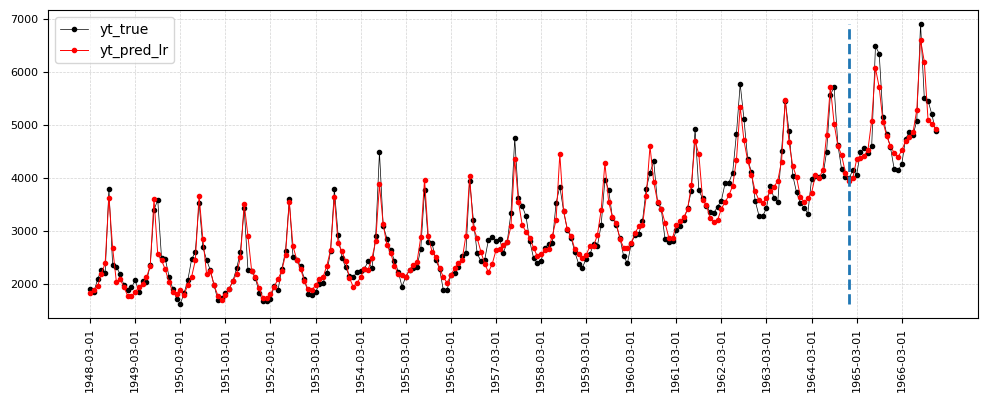

In [6]:
#
# Promedio de los pronosticos
#
from sklearn.linear_model import LinearRegression

model = LinearRegression()
X = df_dropna.drop(columns=["yt_true", "yt_pred_mean"])
y = df_dropna["yt_true"]
model.fit(X, y)
df_dropna["yt_pred_lr"] = model.predict(X)
functions.plot_time_series(df=df_dropna[["yt_true", "yt_pred_lr"]], yt_col="yt_true")
